# 17 — Multi-panel figures: `grid`, `facet`, `shared_colorbar`

One map answers one question. Comparison needs several panels that agree on everything except the thing being
compared — same projection, same framing, same colour scale — because any difference a reader can see, they will
read as signal.

`digitalearth.static` has three module-level functions for this. They are functions rather than `Map` methods
precisely because they compose *across* scenes rather than acting on one.

| function | what it does |
|---|---|
| `grid(nrows, ncols, ...)` | builds a figure and axes grid, binds a `Map` to each |
| `facet(stack, ...)` | one panel per item in a stack, drawn for you |
| `shared_colorbar(fig, mappable, maps)` | one colour bar serving every panel |

API: [`Scenes & multi-panel figures`](../reference/static_scene.md).

> **Where this data comes from.** Everything in this notebook is real, downloaded with
> [earthlens](https://github.com/serapeum-org/earthlens) and committed under `examples/data/`:
> WorldPop population grids, OpenStreetMap roads, GBIF bird occurrences and geoBoundaries admin
> polygons. `examples/data/ATTRIBUTION.md` records each source and its licence.


**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits two levels up: docs/examples -> repo root.
DATA = Path("../../examples/data")

# UTM zone 32N: a metric CRS, correct for south-west Germany.
UTM32 = 25832


## The data

Two **WorldPop** 1 km population grids for Germany, ten years apart. A real before-and-after pair is the
situation faceting exists for — and it is a genuine test of whether the figure is honest, because the change
between them is small relative to the pattern.

In [2]:
pop10 = Dataset.read_file(str(DATA / "germany_pop_2010_1km.tif"))
pop20 = Dataset.read_file(str(DATA / "germany_pop_2020_1km.tif"))
states = FeatureCollection.read_file(str(DATA / "germany_adm1.geojson"))
print(f"2010: {pop10.rows}x{pop10.columns}   2020: {pop20.rows}x{pop20.columns}   EPSG:{pop20.epsg}")

2010: 934x1100   2020: 934x1100   EPSG:4326


## `grid` — a figure of maps you fill yourself

`grid` returns `(fig, maps)`: the figure, and a flat list of `Map` objects already bound to each axes. You draw
whatever you like on each. Use it when the panels differ in *kind*, not just in data.

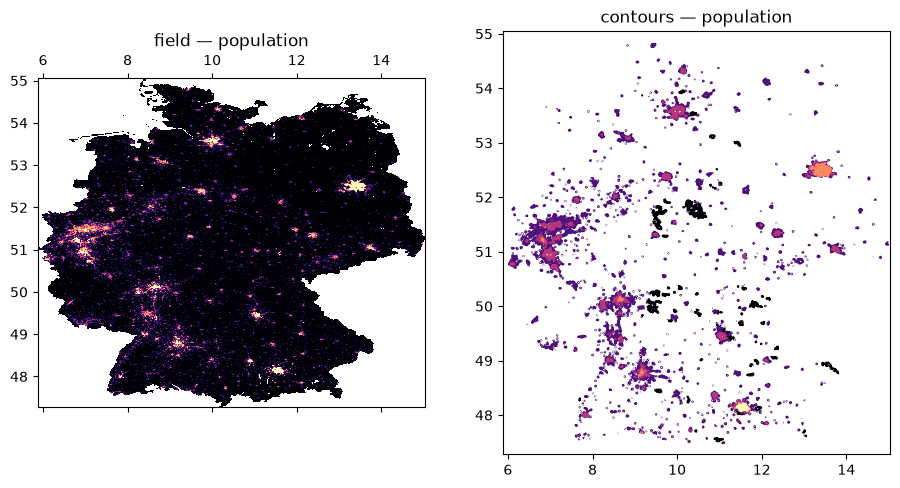

In [3]:
from digitalearth.static import grid

fig, panels = grid(1, 2, crs=pop20.epsg, figsize=(11, 5.5))
panels[0].field(pop20, cmap="magma", vmin=0, vmax=2000)
panels[0].set_title("field — population")
panels[1].contours(pop20, cmap="magma", levels=6)
panels[1].set_title("contours — population")
fig;

Two renderings of one raster sharing a projection and a layout. Because each panel is a full `Map`, everything
from the rest of this gallery works inside it — layers, insets, decoration.

## `sharex` / `sharey` and `suptitle`

Shared axes lock the panels' coordinates together, so a feature at the same place appears at the same position in
every panel. `suptitle` names the figure as a whole.

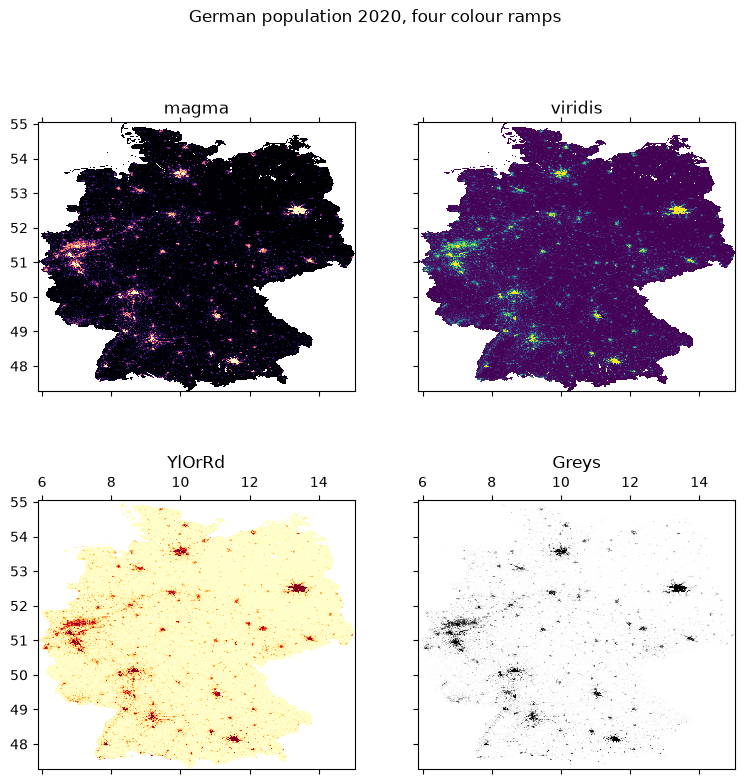

In [4]:
fig, panels = grid(2, 2, crs=pop20.epsg, figsize=(9, 9), sharex="all", sharey="all",
                   suptitle="German population 2020, four colour ramps")
for panel, cmap in zip(panels, ("magma", "viridis", "YlOrRd", "Greys")):
    panel.field(pop20, cmap=cmap, vmin=0, vmax=2000)
    panel.set_title(cmap)
fig;

Four ramps over identical data is a useful exercise in itself: how much structure you "see" changes a great deal
with the ramp, which is an argument for choosing one deliberately rather than taking the default.

## `facet` — one panel per item, drawn for you

Where `grid` gives empty panels, `facet` takes a **stack** and draws it: one panel per item, same `kind`, same
colour scale, with a colour bar. This is the tool for a time series or an ensemble.

| argument | meaning | typical value |
|---|---|---|
| `stack` | the rasters to draw, one per panel | a list of `Dataset`, or a collection |
| `labels` | per-panel titles | a sequence as long as the stack |
| `col_wrap` | panels per row before wrapping | an integer |
| `kind` | how each panel is drawn | `"field"` (default), `"contours"`, … |
| `colorbar` | draw the shared bar | `True` (default) |

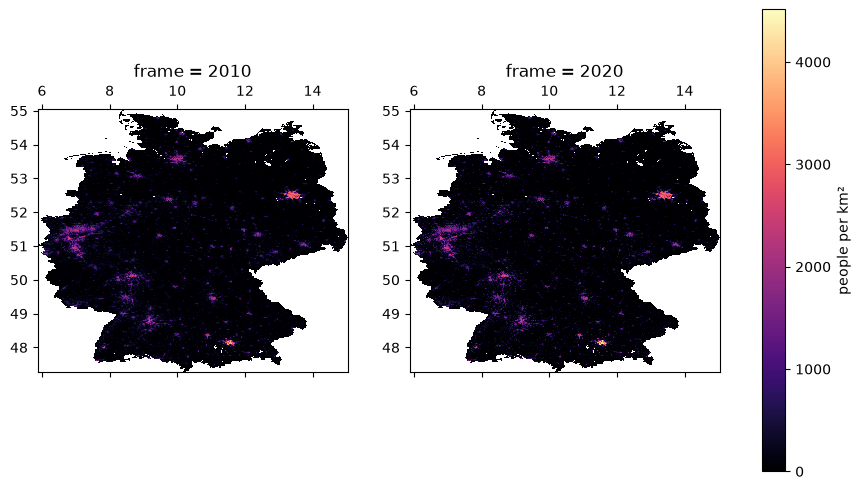

In [5]:
from digitalearth.static import facet

fig, panels = facet(
    [pop10, pop20],
    crs=pop20.epsg,
    figsize=(11, 6),
    labels=["2010", "2020"],
    cmap="magma",
    cbar_label="people per km²",
)
fig;

Two panels, one colour scale, one bar. The shared scale is the critical part: because both panels use it, any
difference you can see between them is a real difference in population. Had each panel been normalised to its
own range, both would look nearly identical and the figure would say nothing — the single most common way a
comparison figure misleads.

## Seeing the change directly

Even with a shared scale, a decade of population change is hard to read from two near-identical maps. The honest
way to show a small difference is to map the difference itself.

In [6]:
from pyramids.base.georeference import GeoReference

a = pop10.read_array(band=0).astype("float32")
b = pop20.read_array(band=0).astype("float32")
valid = (a > -1000) & (b > -1000)
change = ((b - a) * valid).astype("float32")
print(f"change range: {change.min():.0f} to {change.max():.0f} people per km²")

change range: -702 to 1051 people per km²


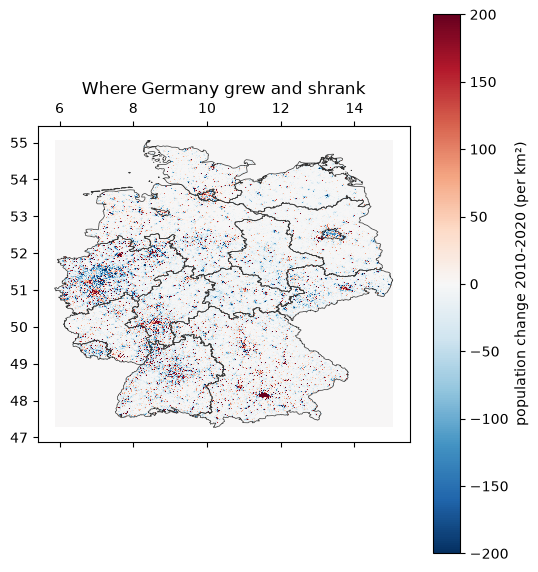

In [7]:
ref = GeoReference(geo=pop20.geotransform, epsg=pop20.epsg)
delta = Dataset.from_array(change, geo_ref=ref)
m = Map(crs=pop20.epsg, figsize=(6, 7))
m.field(delta, cmap="RdBu_r", vmin=-200, vmax=200)
m.polygons(states, edgecolor="#333333", linewidth=0.5)
m.colorbar(label="population change 2010-2020 (per km²)")
m.set_title("Where Germany grew and shrank")
m.fig;

This is the figure the facet pair could not give: growth in red around the big cities, decline in blue across
much of the east. A diverging ramp centred on zero is the right choice here, and pinning `vmin`/`vmax`
symmetrically is what keeps white meaning "no change" instead of drifting to wherever the data's midpoint
happens to fall.

## `shared_colorbar` — one bar across panels you built with `grid`

`facet` adds its bar for you. When you built the panels yourself, `shared_colorbar` does the same job: pass the
figure, one panel's artist as the mappable, and the panels the bar should span.

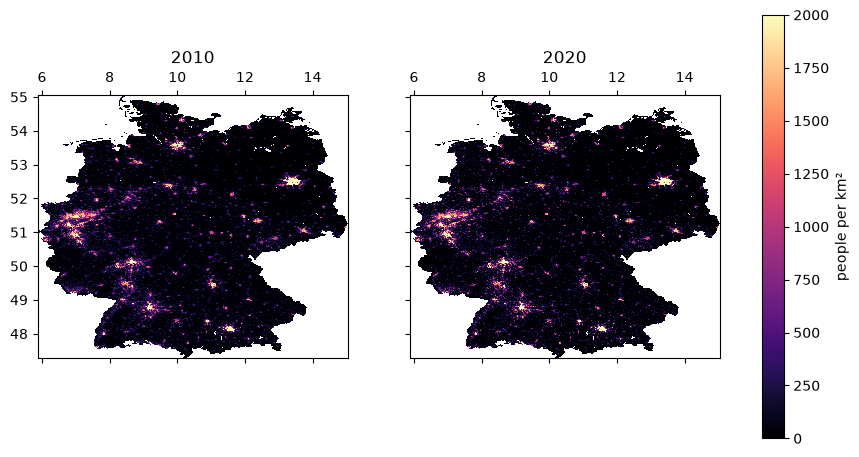

In [8]:
from digitalearth.static import shared_colorbar

fig, panels = grid(1, 2, crs=pop20.epsg, figsize=(11, 5.5), sharey="all")
for panel, (ras, year) in zip(panels, ((pop10, "2010"), (pop20, "2020"))):
    panel.field(ras, cmap="magma", vmin=0, vmax=2000)
    panel.set_title(year)
bar = shared_colorbar(fig, panels[0].artist(), panels, label="people per km²")
fig;

Note `vmin`/`vmax` passed explicitly to every panel. A shared bar is only honest if the panels really do share a
scale — the bar does not impose one, it *reports* one. Pinning the limits is what makes it true, and leaving them
out is how a shared bar ends up lying about panels that were each scaled independently.

## Takeaway

- `grid(nrows, ncols)` → `(fig, maps)`: empty panels you fill, for comparisons across *kinds*.
- `facet(stack)` → one panel per item with a shared scale and bar, for comparisons across *data*.
- `shared_colorbar` adds one bar to panels you built yourself — after pinning `vmin`/`vmax` so the shared scale
  is real.
- When the difference between panels is small, map the **difference** instead, on a diverging ramp centred on
  zero.

Next: [`18_global_decorations`](18_global_decorations.ipynb).